In this lab we will cover the three themes that you saw during the course: **Validation, Reproducibility and Interpretability**.

The outline of this notebook is:
1. **Validation: general rules using the digits dataset**: In this section we will illustrate the main concepts of validation: performing cross-validation, choose relevant metrics and making sure our code is reproducible.
2. **Validation: specific rules to medical applications**: In this section, we will highlight cross-validation rules that are specific to medical applications.
3. **Interpretability**: In this section we provide some basic tools to interpret a model and external resources for in-depth information.
4. **[Optional]: Making your own functions/classes for cross-validation**: If you have some spare time, we strongly encourage you to implement yourself cross-validation schemes. We provide templates for several schemes and tests to check your implementations.

# 1. Validation: general rules using the digits dataset

In this section we will work on the *digits* dataset. Let's load it and have a look at some images.

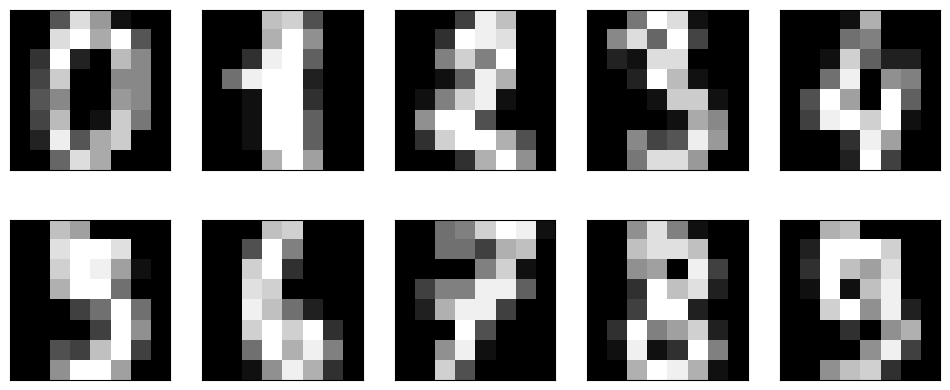

In [ ]:
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import pandas as pd
import scipy
%matplotlib inline

# Load the digits dataset
X, y = load_digits(return_X_y=True)

# Plot the first image for each class
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[y == i][0].reshape(8, 8), cmap='gray')
    plt.xticks([])
    plt.yticks([])

## 1.1 Multiclass classification

First we will work on the 10-class classification task, that is predicting the digit given the image.

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Are the classes balanced? Compute the frequencies of each class.
  You can use <a href="https://docs.scipy.org/doc/numpy/reference/generated/numpy.unique.html">numpy.unique</a>
  or <a href="https://docs.scipy.org/doc/numpy/reference/generated/numpy.bincount.html">numpy.bincount</a>.
  Is the <i>accuracy</i> a relevant metric for this use case?
</div>

In [ ]:
np.bincount(y) / y.size  # or np.unique(y, return_counts=True)[1] / y.size

array([0.09905398, 0.10127991, 0.0984975 , 0.10183639, 0.10072343,
       0.10127991, 0.10072343, 0.09961046, 0.09682805, 0.10016694])

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Fit a classifier and evaluate its performance.
  If you are not familiar with <code>scikit-learn</code>, have
  a look at the <a href="https://scikit-learn.org/stable/modules/classes.html">API Reference</a> to choose a classifier,
  then at the documentation of this classifier to know how to use it.
</div>

Here is a quick example in case that you are not familiar with ``scikit-learn``:

```
from sklearn.svm import SVC  # Import the class defining the type of classifier
from sklearn.metrics import accuracy_score  # Import the function defining the metric used
clf = SVC()  # Define an instance of the class
clf.fit(X, y)  # Fit the classifier
y_pred = clf.predict(X)  # Get the predictions of the classifier for the given input data
clf.score(X, y)  # Compute directly the accuracy score for the given input data
accuracy_score(y, y_pred)  # Compute the accuracy score for the given predictions
```



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier()
clf.fit(X, y)

print('Accuracy = {:.4f}'.format(clf.score(X, y)))

Accuracy = 1.0000


If you have a classifier that returns perfect predictions, you probably did not use cross-validation...

When you take an exam, are the questions the same as the ones from the exam of the previous year? You would love to, but it is not the case, **because the teacher wants to know what you learned, not if you are able to copy-paste**.

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Fit your model on a training set and evaluate its performance on the training set and the test set.
  You can use <a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html">sklearn.model_selection.train_test_split</a>
  to split your dataset into a training set and a test set.
</div>

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

clf = GradientBoostingClassifier()
clf.fit(X_train, y_train)

print('Accuracy on the training set = {:.4f}'.format(clf.score(X_train, y_train)))
print('Accuracy on the test set = {:.4f}'.format(clf.score(X_test, y_test)))

Accuracy on the training set = 1.0000
Accuracy on the test set = 0.9689


Compare both scores:
* Does your model have a higher score on the training set than on the test set? Your model is over-fitting.
* Does your model have a higher score on the test set than on the training set? Your model is under-fitting.
* Does your model have similar scores on both sets? Your model is fitting well.

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Run the previous code cell several times. Do you get the same results everytime?
  Whatever your answer, look at your code and see if there is any kind of randomness.
  If there is randomness, find how to fix it by looking at the documentation of the relevant functions and classes.
</div>

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,80,255,0.4); padding:20px'>
  <b>Solution</b>: Splitting the dataset into a training set and a test set involves randomness. To fix the seed of the random number generator, use the random_state parameter of the sklearn.model_selection.train_test_split function.
Moreover, your classifier might also involve randomness. To check this, you must check if the class has a random_state parameter.
More generally, everytime there is randomness in a scikit-learn algorithm, it can be fixed via the random_state parameter. See the random-state entry in the glossary of scikit-learn.
</div>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

clf = GradientBoostingClassifier(random_state=42)
clf.fit(X_train, y_train)

print('Accuracy on the training set = {:.4f}'.format(clf.score(X_train, y_train)))
print('Accuracy on the test set = {:.4f}'.format(clf.score(X_test, y_test)))

Accuracy on the training set = 1.0000
Accuracy on the test set = 0.9711


For the moment, we used a classifier with only one combination of hyper-parameters (probably the default values). However, these values may not be optimal. **It is import not to use the test set to find the optimal values! You must only use the training set to find them. Do the teacher assistants, who has access to the exam, tell you know which chapters you must focus on and which chapters you can skip? Of course they don't!**

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Find relevant hyper-parameters for the classifier that you chose and try out several values for each of them.
  You can have a look at
  <a href="https://scikit-learn.org/stable/modules/grid_search.html">Tuning the hyper-parameters of an estimator </a>
  from <code>scikit-learn</code> documentation.
</div>

The main idea is to provide a dictionary for <code> param_grid </code>
if you use <code>GridSearchCV</code> or <code>param_distributions</code>
if you use <code>RandomizedSearchCV</code>,
where the keys correspond to the parameters and the values correspond to the
values for each parameter (an iterable for each parameter if using a grid search,
a distribution for each parameter if using a randomized search).

```
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define a grid with a single parameter, C, and the values tested are 1, 10, 100
clf = GridSearchCV(SVC(), param_grid={'C': (1, 10, 100)})

# Fit the classifier (it will automatically performe cross-validation)
clf.fit(X, y)
```

In [ ]:
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

clf = GridSearchCV(GradientBoostingClassifier(random_state=42),
                   {'max_depth': [2, 3, 4], 'min_samples_split': [2, 4, 8]}, cv=5)
clf.fit(X_train, y_train)

print('Accuracy on the training set = {:.4f}'.format(clf.score(X_train, y_train)))
print('Accuracy on the test set = {:.4f}'.format(clf.score(X_test, y_test)))

Accuracy on the training set = 1.0000
Accuracy on the test set = 0.9667


So far we split the dataset into a training set and a test set only once. This might not be ideal, especially if the dataset is small, because we estimate the predictive performance with a small sample size, and the variance may be high. To tackle this issue, one solution is **cross-validation** (CV). In this procedure a test set should be held out for final evaluation, but the validation set is no longer needed when doing CV. The training set is split into k smaller sets. The following procedure is followed for each of the k “folds” :
- A model is trained using (k-1) of the folds as training data
- The model is validated on the remaining part of the data
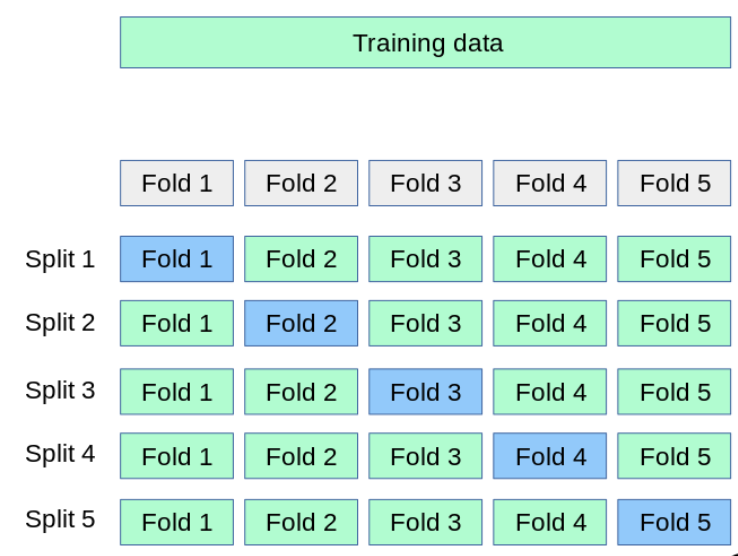


In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Perform a 5 fold cross-validation using the KFold function of sklearn
      (see <a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html">KFold</a>) and evaluate your 5 models on the test set </li>

</div>

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
clf = GradientBoostingClassifier(random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


kf = KFold(n_splits=5)
kf.get_n_splits(X_train)

for i, (train_index, test_index) in enumerate(kf.split(X_train)):

    print(f"Fold {i}:")
    X_t, X_val = X[train_index], X[test_index]
    y_t, y_val = y[train_index], y[test_index]

    clf.fit(X_t, y_t)

    print('Accuracy on the training set = {:.4f}'.format(clf.score(X_t, y_t)))
    print('Accuracy on the remaining set = {:.4f}'.format(clf.score(X_val, y_val)))
    print('Accuracy on the test set = {:.4f}'.format(clf.score(X_test, y_test)))

    print()

Fold 0:
Accuracy on the training set = 1.0000
Accuracy on the remaining set = 0.8852
Accuracy on the test set = 0.9533

Fold 1:
Accuracy on the training set = 1.0000
Accuracy on the remaining set = 0.9296
Accuracy on the test set = 0.9622

Fold 2:
Accuracy on the training set = 1.0000
Accuracy on the remaining set = 0.9219
Accuracy on the test set = 0.9667

Fold 3:
Accuracy on the training set = 1.0000
Accuracy on the remaining set = 0.9368
Accuracy on the test set = 0.9644

Fold 4:
Accuracy on the training set = 1.0000
Accuracy on the remaining set = 0.9331
Accuracy on the test set = 0.9756



## 1.2 Binary classification

Now we will work on a binary classification task: predicting if the digit is one of {3, 6} or not:
$$ \tilde{y} = \begin{cases} 1 & \text{if } y \in \{3, 6\} \\ 0 & \text{otherwsie} \\ \end{cases} $$

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Define the new target vector <code>y_binary</code>.
  You can use the <a href="https://docs.scipy.org/doc/numpy/reference/generated/numpy.isin.html">numpy.isin</a> function and the
  <a href="https://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.astype.html">astype</a> method.
</div>

In [ ]:
y_binary = np.isin(y, [3, 6]).astype('int64')

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Are the classes balanced? Find a relevant metric for this use case.
  You can have a look at the
  <a href="https://scikit-learn.org/stable/modules/classes.html#classification-metrics">Classification metrics</a>
  section in the API documentation of <code>scikit-learn</code>.
</div>

In [ ]:
np.bincount(y_binary) / y.size

array([0.79744018, 0.20255982])

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Fit a classifier. Do you get good results?
  If not, look at the predictions made by your classifier.
  Compare your performance to a dummy classifier like
  <a href="https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html">sklearn.dummy.DummyClassifier</a>
  or to random predictions using <a href="https://docs.scipy.org/doc/numpy-1.15.0/reference/generated/numpy.random.choice.html">
  numpy.random.choice </a>.
</div>

In [ ]:
from sklearn.metrics import balanced_accuracy_score

X_train, X_test, y_binary_train, y_binary_test = train_test_split(X, y_binary, random_state=42)

clf = GradientBoostingClassifier(random_state=42)
clf.fit(X_train, y_binary_train)

print('Balanced accuracy on the training set = {:.4f}'.format(
    balanced_accuracy_score(y_binary_train, clf.predict(X_train))))
print('Balanced accuracy on the test set = {:.4f}'.format(
    balanced_accuracy_score(y_binary_test, clf.predict(X_test))))

Balanced accuracy on the training set = 0.9982
Balanced accuracy on the test set = 0.9656


It is possible that your classifier predicts too many zeros, which is the majority class. Many algorithms consist in minimizing a loss function:
$$ L(X, Y) = \frac{1}{n} \sum_{i=1}^n \ell\big(y_i, f(x_i; \theta)\big) + \lambda \text{ Reg}(\theta) $$

When the classes are imbalanced, the algorithm can get a good (i.e. small) loss by always predicting the majority class. Such a classifier is not useful, as the accuracy is not a good metric.

Two popular approaches to tackle imbalanced datasets are:
* **Resampling**: resampling the dataset can lead to a more robust and fair decision boundary. There are several resampling strategies:
    * Over-sampling: Over-sampling the minority classes by creating new samples
    * Under-sampling: Under-sampling the majority classes
    * Combination of over- and under-sampling
  
* **Cost-sensitive learning**: Cost-sensitive learning consists in giving different weights to different samples based on their classes. In the case of minimizing a loss function, it looks like this:
$$ L(X, Y) = \sum_{i=1}^n {\color{red} {w_i}} \ell\big(y_i, f(x_i; \theta)\big) + \lambda \text{ Reg}(\theta) $$
where
$$ w_i = \begin{cases} w_{1} & \text{if } y_i = 1 \\ w_{0} & \text{if } y_i = 0 \\ \end{cases} $$
with $ w_{1} > w_{0} $. Cost-sensitive learning can be performed using the `class_weight` parameter for a `scikit-learn` classifier. It is also possible to provide the `sample_weight` parameter in the `fit` method

External resources:
* [class_weight](https://scikit-learn.org/stable/glossary.html#term-class-weight) entry in `scikit-learn` glossary.
* [sample_weight](https://scikit-learn.org/stable/glossary.html#term-sample-weight) entry in `scikit-learn` glossary.
* Python package [imbalanced-learn](https://github.com/scikit-learn-contrib/imbalanced-learn).

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Try one approach to tackle the class imbalance and see if you get better results.
</div>

In [ ]:
X_train, X_test, y_binary_train, y_binary_test = train_test_split(X, y_binary, random_state=42)


print(y_binary_train)
print(np.bincount(y_binary_train))
sample_weight = (y_binary_train.size / (np.bincount(y_binary_train) * 2))[y_binary_train]

clf = GradientBoostingClassifier(random_state=42)
clf.fit(X_train, y_binary_train, sample_weight=sample_weight)

print('Balanced accuracy on the training set = {:.4f}'.format(
    balanced_accuracy_score(y_binary_train, clf.predict(X_train))))
print('Balanced accuracy on the test set = {:.4f}'.format(
    balanced_accuracy_score(y_binary_test, clf.predict(X_test))))

[0 0 0 ... 0 0 0]
[1074  273]
Balanced accuracy on the training set = 0.9995
Balanced accuracy on the test set = 0.9848


In [ ]:
sample_weight

array([0.62709497, 0.62709497, 0.62709497, ..., 0.62709497, 0.62709497,
       0.62709497])

In [ ]:
(y_binary_train.size / (np.bincount(y_binary_train) * 2))

array([0.62709497, 2.46703297])

If you used over-sampling and get much better results, are you sure that you did not perform any kind of data leakage?

More information on this in the next section!

To better compare the performance of different models, it is interesting to better grasp the precision of the performance estimates of a given model. For this, we can take into account different sources of variability, in the evaluation of the trained model or in its learning procedure.
For instance, variability may arise from the choice of test set, from the data order during training, from the random initialisation of weights before training, etc.

So far we split the dataset into a training set and a test set only once. This may not be ideal, especially if the dataset is small, because we estimate the predictive performance with a small sample size, and the variance may be high. To tackle this issue, we will perform bootstrapping. In other words, we will create new test sets by sampling with replacement from the original test set, evaluate the performance of our model on these different test sets, and then derive the mean, the standard error of the mean, and confidence intervals from the performance on the different test sets.

**Tips**: we recommend to use ```pandas.Dataframe```, especially the method [```sample```](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html):


In [ ]:
df = pd.DataFrame(columns=['true_label', 'predicted_label'])

df['true_label'] = y_binary_test
df['predicted_label'] = clf.predict(X_test)

In [ ]:
from sklearn.metrics import balanced_accuracy_score

mean : 0.9847685264393106
SEM* : 0.008143230829190223
Confidence interval : [0.9665, 0.9986]


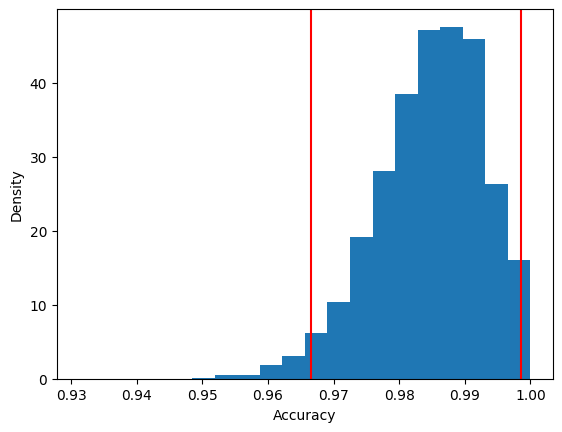

In [ ]:
# Function to compute the accuracy
def compute_accuracy(df):
    return balanced_accuracy_score(df['true_label'], df['predicted_label'])

# Bootstrapping N times
N = 15
accuracies = []
for i in range(N):
    df_bootstrap = df.sample(replace=True, n=len(df))
    accuracy_df_bootstrap = compute_accuracy(df_bootstrap)
    accuracies.append(accuracy_df_bootstrap)

# Plot the histogram of accuracies, to get a grasp of the variability
plt.hist(accuracies, bins=20, density=True)

# Compute the mean and the SEM
accuracies = np.array(accuracies)
print("mean : " + str(accuracies.mean()) )
print("SEM* : " + str(accuracies.std()) )

# Compute the confidence intervals and plot them
lower_bound_ci =  np.percentile(accuracies, 2.5 )
upper_bound_ci = np.percentile(accuracies, 97.5 )
print(f"Confidence interval : [{round(lower_bound_ci, 4)}, {round(upper_bound_ci, 4)}]")
plt.xlabel('Accuracy')
plt.ylabel('Density')
plt.axvline(x=lower_bound_ci, c='red')
plt.axvline(x=upper_bound_ci, c='red')
plt.show()

Conclusion. In general, it is a good practice to perform bootstrapping on the test set as it allows to obtain more robust performance estimates.

## 1.3 Preprocessing

Preprocessing your dataset is (almost always) a necessary step in machine learning. Preprocessing includes imputing missing values, standardizing or scaling your features, performing feature selection. All the information that must be computed on the training set:
* **Imputing missing values**: If you want to compute statistics such as means, median or most frequent values, you must compute them using the training set only.
* **Scaling features**: If you want to standardize/scale features, you must compute the corresponding statistics (mean, standard deviation, min, max, etc.) using the training set only.
* **Selecting feature**: If you want to select features using a criterion (let's say a univariate statistical test), you must compute the statistics/p-values using the training set only.
* **Resampling**: If you want to resample your data set, you must do it only on the training set.

Pipelines are a great and not-so-well known tool from `scikit-learn`. A [sklearn.pipeline.Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline) can be used to chain multiple estimators into one. Pipelines serve multiple purposes:

* **Convenience and encapsulation**: You only have to call fit and predict once on your data to fit a whole sequence of estimators.
* **Joint parameter selection**: You can grid search over parameters of all estimators in the pipeline at once.
* **Safety**: Pipelines help avoid leaking statistics from your test data into the trained model in cross-validation, by ensuring that the same samples are used to train the transformers and predictors.

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Perform over-sampling using
  <a href="https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html">imblearn.over_sampling.SMOTE</a>.
  Do it in two different ways:
  <ul>
    <li> First, perform over-sampling using the whole data set and estimate the predictive performance on the test set;</li>
    <li> Then, perform over-sampling using only the training set by using a
      <a href="https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html#imblearn.pipeline.Pipeline">imblearn.pipeline.Pipeline</a>
      and estimate the predictive performance on the test set.</li>
  </ul>
  Compare both scores.
</div>

In [ ]:
!pip install imbalanced-learn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y_binary)

X_train, X_test, y_binary_train, y_binary_test = train_test_split(X_res, y_res, random_state=42)

clf = GradientBoostingClassifier(random_state=42)
clf.fit(X_train, y_binary_train)

print('Balanced accuracy on the training set = {:.4f}'.format(
    balanced_accuracy_score(y_binary_train, clf.predict(X_train))))
print('Balanced accuracy on the test set = {:.4f}'.format(
    balanced_accuracy_score(y_binary_test, clf.predict(X_test))))

Balanced accuracy on the training set = 0.9991
Balanced accuracy on the test set = 0.9931


In [ ]:
from imblearn.pipeline import Pipeline

X_train, X_test, y_binary_train, y_binary_test = train_test_split(X, y_binary, random_state=42)

pipeline = Pipeline([('smote', SMOTE(random_state=42)),
                     ('clf', GradientBoostingClassifier(random_state=42))])

pipeline.fit(X_train, y_binary_train)

print('Balanced accuracy on the training set = {:.4f}'.format(
    balanced_accuracy_score(y_binary_train, pipeline.predict(X_train))))
print('Balanced accuracy on the test set = {:.4f}'.format(
    balanced_accuracy_score(y_binary_test, pipeline.predict(X_test))))

Balanced accuracy on the training set = 1.0000
Balanced accuracy on the test set = 0.9752


In [ ]:
#@title
%%html
<div style='background-color:rgba(255,80,80,0.4); padding:20px'>
  <b>Take-home message: If you want to perform any kind of preprocessing,
    you must fit the corresponding estimators on the training set only.</b>
</div>

# 2. Validation: specific rules to medical applications

In the previous section we highlighted rules for cross-validation that address the most common situations. However, for some medical applications, the datasets can be slightly different and more care is needed. We will illustrate this with a 2D CNN trained on slices extracted from a MRI volume.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
from os import path
import pandas as pd
from copy import deepcopy
import numpy as np
from time import time

## 2.1 MRI Dataset

We use the same MR images as in the first lab. Run the following command to download them.

In [ ]:
! git clone https://github.com/14thibea/OASIS-1_dataset.git

Cloning into 'OASIS-1_dataset'...
remote: Enumerating objects: 675, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 675 (delta 21), reused 31 (delta 7), pack-reused 627
Receiving objects: 100% (675/675), 1.31 GiB | 17.75 MiB/s, done.
Resolving deltas: 100% (452/452), done.
Updating files: 100% (576/576), done.


A Dataset object is used to extract slices from the preprocessed data. Please refer to the [previous lab](https://colab.research.google.com/drive/1Wb8sNyK6hRnxNZRInGC9URTElYWtJQZ4#scrollTo=66NAk4C-spYh) for more information on the preprocessing steps.

In [ ]:
class MRIDataset(Dataset):
    """A dataset that will extract slices from MRI volumes depending on their
    indices"""

    def __init__(self, img_dir, data_df):
        """
        Args:
          img_dir: (str) path to the directory containing the images.
          data_df: (DataFrame) list of subjects and slice indices.
          Mandatory columns are participant_id, session_id, diagnosis and slice_id.
        """
        self.img_dir = img_dir
        self.data_df = data_df.reset_index()
        self.label_code = {"AD":1, "CN":0}

        mandatory_columns = {'participant_id', 'session_id', 'diagnosis', 'slice_id'}
        if not isinstance(data_df, pd.DataFrame):
            raise TypeError("data_df must be a DataFrame")
        elif not mandatory_columns.issubset(data_df.columns.values):
            raise ValueError("data_df must include mandatory columns that are " +
                             str(mandatory_columns))
        self.size = self[0]['image'].shape

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        diagnosis = self.data_df.loc[idx, 'diagnosis']
        label = self.label_code[diagnosis]

        participant_id = self.data_df.loc[idx, 'participant_id']
        session_id = self.data_df.loc[idx, 'session_id']
        filename = participant_id + '_' + session_id + \
          '_T1w_segm-graymatter_space-Ixi549Space_modulated-off_probability.pt'

        image = torch.load(path.join(self.img_dir, filename))

        # Slice extraction
        slice_id = self.data_df.loc[idx, 'slice_id']
        image = image[:, :, slice_id, :].clone().repeat(3, 1, 1)

        sample = {'image': image, 'label': label,
                  'participant_id': participant_id,
                  'session_id': session_id,
                  'slice_id': slice_id}
        return sample

30 slices are extracted from the coronal plane for each subject.
The slices of one subject are displayed below.

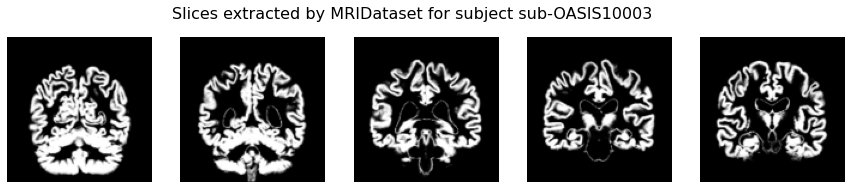

In [ ]:
import matplotlib.pyplot as plt
import nibabel as nib
from scipy.ndimage import rotate

subject = 'sub-OASIS10003'
preprocessed_pt = torch.load('OASIS-1_dataset/preprocessed/%s_ses-M00_' % subject +
                    'T1w_segm-graymatter_space-Ixi549Space_modulated-off_' +
                    'probability.pt')

def show_slices(slices, subject):
    """ Function to display a row of image slices """
    fig, axes = plt.subplots(1, len(slices), figsize=(3 * len(slices), 3))
    fig.suptitle('Slices extracted by MRIDataset for subject %s' % subject,
                 fontsize=16)
    for i, slice in enumerate(slices):
        axes[i].imshow(slice.T, cmap="gray", origin="lower")
        axes[i].axis("off")

slice_0 = preprocessed_pt[0, :, 45, :]
slice_1 = preprocessed_pt[0, :, 52, :]
slice_2 = preprocessed_pt[0, :, 60, :]
slice_3 = preprocessed_pt[0, :, 67, :]
slice_4 = preprocessed_pt[0, :, 74, :]
show_slices([slice_0, slice_1, slice_2, slice_3, slice_4], subject)
plt.show()

## 2.2 Train and test functions

Main difference with previous lab, the training loss is estimated from batch seen during the epochs instead of testing the whole dataset at the end of the epoch.

In [ ]:
def train(model, train_loader, criterion, optimizer, n_epochs):
    """
    Method used to train a CNN

    Args:
        model: (nn.Module) the neural network
        train_loader: (DataLoader) a DataLoader wrapping a MRIDataset
        criterion: (nn.Module) a method to compute the loss of a mini-batch of images
        optimizer: (torch.optim) an optimization algorithm
        n_epochs: (int) number of epochs performed during training

    Returns:
        best_model: (nn.Module) the trained neural network
    """
    best_model = deepcopy(model)
    train_best_loss = np.inf

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        t0 = time()
        for i, data in enumerate(train_loader, 0):
            images, labels = data['image'].cuda(), data['label'].cuda()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            total_loss += loss.item()
            optimizer.step()
            optimizer.zero_grad()

        mean_loss = total_loss / len(train_loader.dataset)
        print('Epoch %i: loss = %f' % (epoch, mean_loss))

        if mean_loss < train_best_loss:
            best_model = deepcopy(model)
            train_best_loss = mean_loss

    return best_model

def test(model, data_loader, criterion):
    """
    Method used to test a CNN

    Args:
        model: (nn.Module) the neural network
        data_loader: (DataLoader) a DataLoader wrapping a MRIDataset
        criterion: (nn.Module) a method to compute the loss of a mini-batch of images

    Returns:
        results_df: (DataFrame) the label predicted for on the slice level.
        results_metrics: (dict) a set of metrics
    """
    model.eval()
    columns = ["participant_id", "slice_id", "proba0", "proba1",
               "true_label", "predicted_label"]
    results_df = pd.DataFrame(columns=columns)
    total_loss = 0

    with torch.no_grad():
        for i, data in enumerate(data_loader, 0):
            images, labels = data['image'].cuda(), data['label'].cuda()
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            probs = nn.Softmax(dim=1)(outputs)
            _, predicted = torch.max(outputs.data, 1)

            for idx, sub in enumerate(data['participant_id']):
                row = [sub, data['slice_id'][idx],
                       probs[idx, 0].item(), probs[idx, 1].item(),
                       labels[idx].item(), predicted[idx].item()]
                row_df = pd.DataFrame([row], columns=columns)
                results_df = pd.concat([results_df, row_df])

    results_metrics = compute_metrics(results_df.true_label.values, results_df.predicted_label.values)
    results_df.reset_index(inplace=True, drop=True)
    results_metrics['mean_loss'] = total_loss / len(data_loader.dataset)

    return results_df, results_metrics


def compute_metrics(ground_truth, prediction):
    """Computes the accuracy, sensitivity, specificity and balanced accuracy"""
    tp = np.sum((prediction == 1) & (ground_truth == 1))
    tn = np.sum((prediction == 0) & (ground_truth == 0))
    fp = np.sum((prediction == 1) & (ground_truth == 0))
    fn = np.sum((prediction == 0) & (ground_truth == 1))

    metrics_dict = dict()
    metrics_dict['accuracy'] = (tp + tn) / (tp + tn + fp + fn)

    # Sensitivity
    if tp + fn != 0:
        metrics_dict['sensitivity'] = tp / (tp + fn)
    else:
        metrics_dict['sensitivity'] = 0.0

    # Specificity
    if fp + tn != 0:
        metrics_dict['specificity'] = tn / (fp + tn)
    else:
        metrics_dict['specificity'] = 0.0

    metrics_dict['balanced_accuracy'] = (metrics_dict['sensitivity'] + metrics_dict['specificity']) / 2

    return metrics_dict

## 2.3 Model

As we are working with 2D inputs, we can use networks that have been pretrained on natural images. The last fully-connected layer is replaced to perform a binary classification (indeed the number of classes in the natural images dataset ImageNet is 1,000).

In [ ]:
import torchvision.models as models

def create_model():
    resnet18 = models.resnet18(pretrained=True)
    resnet18.fc = nn.Linear(512, 2)
    return resnet18

## 2.4 Training binary classification (AD vs CN)

As in the previous lab, the goal will be to separate AD patients from CN participants using a CNN. This time its inputs will be slices instead of patches centered on the hippocampus.

In [ ]:
#@title
%%html
<div style='background-color:rgba(255,80,80,0.4); padding:20px'>
    <b>In this lab we don't perform a cross-validation to reduce computational time.
      However it is highly recommended to do it as deep learning methods are not deterministic and
      give highly variable results. In this way a cross-validation procedure can help to better
      estimate the performance and make better choices of hyperparameters.</b>
</div>

### 2.4.1 Slice-level split

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Split your data on the slice level and create two DataFrames
  <code>train_df</code> and <code>valid_df</code>.
  You can use <a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html">sklearn.model_selection.train_test_split</a>
  to split your dataset into a training set and a validation set.<br>
  The dataframe comprising all training data was added on github under the path
  <code>tsv_files/lab_2/train_valid.tsv</code>.
</div>

In [ ]:
from sklearn.model_selection import train_test_split

train_valid_df = pd.read_csv('OASIS-1_dataset/tsv_files/lab_2/train_valid.tsv', sep='\t')

train_df, valid_df = train_test_split(train_valid_df, random_state=42)
train_df.head()

,participant_id,session_id,alternative_id_1,sex,education_level,age_bl,cdr,diagnosis_bl,laterality,MMS,cdr_global,diagnosis,slice_id
2525,sub-OASIS10342,ses-M00,OAS1_0342_MR1,F,2.0,88,0.0,CN,R,28.0,0.0,CN,50
3875,sub-OASIS10352,ses-M00,OAS1_0352_MR1,F,5.0,81,0.5,AD,R,26.0,0.5,AD,50
2465,sub-OASIS10362,ses-M00,OAS1_0362_MR1,F,3.0,63,0.5,AD,R,14.0,0.5,AD,50
343,sub-OASIS10339,ses-M00,OAS1_0339_MR1,F,2.0,79,0.5,AD,R,24.0,0.5,AD,58
3223,sub-OASIS10120,ses-M00,OAS1_0120_MR1,M,4.0,70,0.5,AD,R,26.0,0.5,AD,58


In [ ]:
from sklearn.model_selection import train_test_split

train_valid_df = pd.read_csv('OASIS-1_dataset/tsv_files/lab_2/train_valid.tsv', sep='\t')

indices_train, indices_valid = train_test_split(train_valid_df.index.values, random_state=42)
train_df = train_valid_df.loc[indices_train]
valid_df = train_valid_df.loc[indices_valid]

print(train_valid_df)

      participant_id session_id alternative_id_1 sex  education_level  age_bl  \
0     sub-OASIS10179    ses-M00    OAS1_0179_MR1   F              2.0      87   
1     sub-OASIS10179    ses-M00    OAS1_0179_MR1   F              2.0      87   
2     sub-OASIS10179    ses-M00    OAS1_0179_MR1   F              2.0      87   
3     sub-OASIS10179    ses-M00    OAS1_0179_MR1   F              2.0      87   
4     sub-OASIS10179    ses-M00    OAS1_0179_MR1   F              2.0      87   
...              ...        ...              ...  ..              ...     ...   
3925  sub-OASIS10268    ses-M00    OAS1_0268_MR1   M              2.0      78   
3926  sub-OASIS10268    ses-M00    OAS1_0268_MR1   M              2.0      78   
3927  sub-OASIS10268    ses-M00    OAS1_0268_MR1   M              2.0      78   
3928  sub-OASIS10268    ses-M00    OAS1_0268_MR1   M              2.0      78   
3929  sub-OASIS10268    ses-M00    OAS1_0268_MR1   M              2.0      78   

      cdr diagnosis_bl late

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Train the 2D CNN and evaluate its performance on the training and validation set. You can reuse code from
  <a href="https://colab.research.google.com/drive/1EUB_m9_0i7d1dAr0_ElbJjCXx4W4JqiF#scrollTo=spF8eq2pcGC_">the previous lab</a>.
</div>

In [ ]:
from time import time

# Construction of dataset objects
img_dir = path.join('OASIS-1_dataset', 'preprocessed')
train_dataset = MRIDataset(img_dir, train_df)
valid_dataset = MRIDataset(img_dir, valid_df)

# Try different learning rates
learning_rate = 10**-4
n_epochs = 30
batch_size = 32

# Put the network on GPU
model = create_model().cuda()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
criterion = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), learning_rate)

t= time()
best_model = train(model, train_loader, criterion, optimizer, n_epochs)
print('Execution time', time() - t)

/usr/local/lib/python3.8/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

/usr/local/lib/python3.8/dist-packages/torch/utils/data/dataloader.py:554: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: loss = 0.596668
Epoch 1: loss = 0.225452
Epoch 2: loss = 0.098426
Epoch 3: loss = 0.084951
Epoch 4: loss = 0.057247
Epoch 5: loss = 0.051290
Epoch 6: loss = 0.034804
Epoch 7: loss = 0.050276
Epoch 8: loss = 0.039019
Epoch 9: loss = 0.033194
Epoch 10: loss = 0.034195
Epoch 11: loss = 0.021849
Epoch 12: loss = 0.014041
Epoch 13: loss = 0.006828
Epoch 14: loss = 0.001859
Epoch 15: loss = 0.009148
Epoch 16: loss = 0.029036
Epoch 17: loss = 0.041033
Epoch 18: loss = 0.029633
Epoch 19: loss = 0.009831
Epoch 20: loss = 0.008313
Epoch 21: loss = 0.011073
Epoch 22: loss = 0.019472
Epoch 23: loss = 0.021273
Epoch 24: loss = 0.004878
Epoch 25: loss = 0.004843
Epoch 26: loss = 0.002239
Epoch 27: loss = 0.001265
Epoch 28: loss = 0.000651
Epoch 29: loss = 0.000298
Execution time 222.02369904518127


In [ ]:
valid_result_df, valid_metrics = test(best_model, valid_loader, criterion)
train_results_df, train_metrics = test(best_model, train_loader, criterion)
print("Results on the validation set\n", valid_metrics)
print("Results on the training set\n", train_metrics)

Results on the validation set
 {'accuracy': 0.9450661241098678, 'sensitivity': 0.9457202505219207, 'specificity': 0.9444444444444444, 'balanced_accuracy': 0.9450823474831825, 'mean_loss': 0.1882407555805703}
Results on the training set
 {'accuracy': 1.0, 'sensitivity': 1.0, 'specificity': 1.0, 'balanced_accuracy': 1.0, 'mean_loss': 4.5484235000601945e-05}


The results seem quite good! We can now evaluate the generalization capacity of the network on an independent test set. This set contains subjects that have never been seen during training.

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Evaluate the network on the test set.
  Compare with the scores obtained on the validation set.
  Can you explain the difference?
</div>

In [ ]:
# Construction of test dataloader
test_df = pd.read_csv('OASIS-1_dataset/tsv_files/lab_2/test.tsv', sep='\t')
test_dataset = MRIDataset(img_dir, test_df)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

test_results_df, test_metrics = test(best_model, test_loader, criterion)
print("Results on the test set\n", test_metrics)

Results on the test set
 {'accuracy': 0.6611111111111111, 'sensitivity': 0.5575757575757576, 'specificity': 0.7487179487179487, 'balanced_accuracy': 0.6531468531468532, 'mean_loss': 1.7540191882186467}


### 2.4.2 Subject-level split

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Split your data on the <b>subject level</b> and create two DataFrames
  <code>train_df</code> and <code>valid_df</code>.
</div>

In [ ]:
subjects_train_valid_list = train_valid_df.participant_id.unique()
subjects_train_list, subjects_valid_list = train_test_split(subjects_train_valid_list, random_state=42)

train_df = train_valid_df[train_valid_df.participant_id.isin(subjects_train_list)]
valid_df = train_valid_df[train_valid_df.participant_id.isin(subjects_valid_list)]

In [ ]:
#@title
%%html
<div style='background-color:rgba(80,255,80,0.4); padding:20px'>
  <b>Exercise</b>: Repeat the training and testing steps with the subject-level split.
</div>

In [ ]:
# Construction of dataset objects
img_dir = path.join('OASIS-1_dataset', 'preprocessed')
train_dataset = MRIDataset(img_dir, train_df)
valid_dataset = MRIDataset(img_dir, valid_df)

# Try different learning rates
learning_rate = 10**-4
n_epochs = 30
batch_size = 32

# Put the network on GPU
model = create_model().cuda()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
criterion = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), learning_rate)

best_model = train(model, train_loader, criterion, optimizer, n_epochs)

Epoch 0: loss = 0.593067
Epoch 1: loss = 0.189709
Epoch 2: loss = 0.072330
Epoch 3: loss = 0.056613
Epoch 4: loss = 0.053688
Epoch 5: loss = 0.063442
Epoch 6: loss = 0.065361
Epoch 7: loss = 0.043985
Epoch 8: loss = 0.016993
Epoch 9: loss = 0.014249
Epoch 10: loss = 0.017817
Epoch 11: loss = 0.010684
Epoch 12: loss = 0.009872
Epoch 13: loss = 0.009619
Epoch 14: loss = 0.004379
Epoch 15: loss = 0.002924
Epoch 16: loss = 0.012662
Epoch 17: loss = 0.081169
Epoch 18: loss = 0.040937
Epoch 19: loss = 0.007533
Epoch 20: loss = 0.009583
Epoch 21: loss = 0.003108
Epoch 22: loss = 0.003228
Epoch 23: loss = 0.003593
Epoch 24: loss = 0.005145
Epoch 25: loss = 0.001330
Epoch 26: loss = 0.001617
Epoch 27: loss = 0.002221
Epoch 28: loss = 0.001068
Epoch 29: loss = 0.000570


In [ ]:
valid_result_df, valid_metrics = test(best_model, valid_loader, criterion)
train_results_df, train_metrics = test(best_model, train_loader, criterion)
test_results_df, test_metrics = test(best_model, test_loader, criterion)
print("Results on the training set\n", train_metrics)
print("Results on the validation set\n", valid_metrics)
print("Results on the test set\n", test_metrics)

Results on the training set
 {'accuracy': 1.0, 'sensitivity': 1.0, 'specificity': 1.0, 'balanced_accuracy': 1.0, 'mean_loss': 3.344491961135744e-05}
Results on the validation set
 {'accuracy': 0.6818181818181818, 'sensitivity': 0.6980392156862745, 'specificity': 0.6645833333333333, 'balanced_accuracy': 0.6813112745098039, 'mean_loss': 1.5273729030532066}
Results on the test set
 {'accuracy': 0.6569444444444444, 'sensitivity': 0.5484848484848485, 'specificity': 0.7487179487179487, 'balanced_accuracy': 0.6486013986013985, 'mean_loss': 2.0130998983979227}


## 2.5 Longitudinal dataset

In longitudinal studies, patients have several visits. The dataset could look like this:

In [ ]:
import numpy as np
import pandas as pd

# Create a mock longitudinal dataset
n_patients = 50
n_visits = 4
n_features = 7
patients = ['Patient {}'.format(i + 1) for i in range(n_patients)]
visits = ['Visit {}'.format(i + 1) for i in range(n_visits)]
index = pd.MultiIndex.from_product([patients, visits],
                                   names=['Patient', 'Visit'])
columns = ['Feature {}'.format(i + 1) for i in range(n_features)]
df = pd.DataFrame(data=np.random.randn(len(index), n_features),
                  index=index, columns=columns)
df

Feature 1  Feature 2  Feature 3  Feature 4  Feature 5  \
Patient    Visit                                                            
Patient 1  Visit 1   0.156153   2.112718   0.700607  -0.681635  -1.211849   
           Visit 2   0.820106   0.914594  -0.496036   0.987241  -0.354938   
           Visit 3   0.064828  -0.768956   1.261368   0.340207  -0.474987   
           Visit 4  -0.294296  -0.394838   1.246818   0.307530   1.793342   
Patient 2  Visit 1   1.329138  -0.508277   0.292385  -1.713056  -0.382131   
...                       ...        ...        ...        ...        ...   
Patient 49 Visit 4   0.713299  -0.652525  -0.708518  -0.063677  -1.249107   
Patient 50 Visit 1   0.768347  -1.165753  -0.141512   0.471228   0.131207   
           Visit 2  -0.495492  -0.594635   0.962207   1.934127   0.201370   
           Visit 3  -0.696755  -0.521624   0.107341   0.631866  -2.651518   
           Visit 4  -0.456700   0.807095   0.436895   0.471363   0.031203   

                    Feature 6  Feature 7  
Patient    Visit                          
Patient 1  Visit 1  -1.440367  -1.358110  
           Visit 2   0.577004  -0.219858  
           Visit 3  -1.649822   0.081063  
           Visit 4  -0.397928  -2.551763  
Patient 2  Visit 1   0.075737   1.141416  
...                       ...        ...  
Patient 49 Visit 4  -1.804926  -0.165796  
Patient 50 Visit 1   1.353970   0.704650  
           Visit 2   2.098518  -0.083127  
           Visit 3   1.652605  -0.599205  
           Visit 4  -0.855742   1.222720  

[200 rows x 7 columns]

It is important to split the data set at the patient level, that is all the visits of a given patient belong to one and only set. Why? Because in practice, you will not retrain your model everytime a patient has a new visit. You want your model to be able to generalize for new patients, not only for new visits of patients that were used when fitting the model.

## 2.6 Conclusion

In [ ]:
#@title
%%html
<div style='background-color:rgba(255,80,80,0.4); padding:20px'>
    <b>Take-home message: You must always perform cross-validation at the patient (i.e. sample) level:
      all the observations of a given patient must belong to one and only one set.</b>
</div>

# 3. Interpretability

## 3.1 Machine learning

In many cases, especially medical applications, it is important to have an idea about what the model has learned. Depending on the type of the algorithm (generalized linear model, tree-based algorithm), you can have access to different information.

**(a)** For generalized linear models (linear regression, logistic regression, SVM with a linear kernel, etc.), one can get the coefficients for each feature:
$$ f(x) = f\left( \beta_0 + \sum_{k=1}^K \beta_k x^{(k)}  \right) $$
You can get them via the `intercept_` and `coef_` attributes of a fitted `scikit-learn` estimator.

**(b)** For kernel methods (SVM, Kernel Ridge regression, etc.), one can get the coefficients for each sample in the training set:
$$ f(x) = \beta_0 + \sum_{i=1}^n \beta_i K(x, x_i) $$

You can get them via the `intercept_` and `dual_coef_` attributes of a fitted `scikit-learn` estimator.

**(c)** Tree-based estimators can compute [feature importance scores](https://scikit-learn.org/stable/modules/ensemble.html#feature-importance-evaluation) that represent how much each feature contributes to the predictions:

> The relative rank (i.e. depth) of a feature used as a decision node in a tree can be used to assess the relative importance of that feature with respect to the predictability of the target variable. Features used at the top of the tree contribute to the final prediction decision of a larger fraction of the input samples. The expected fraction of the samples they contribute to can thus be used as an estimate of the relative importance of the features. In scikit-learn, the fraction of samples a feature contributes to is combined with the decrease in impurity from splitting them to create a normalized estimate of the predictive power of that feature.

In [ ]:
#@title
%%html
<div style='background-color:rgba(255,80,80,0.4); padding:20px'>
  <b>Important: The coefficients or feature importance scores depend on the entire dataset:
    if you remove one feature or one sample, you may get different results.</b>
</div>

Section 4 of the user guide of `scikit-learn` provides interesting information regarding interpretability:
* [4. Inspection](https://scikit-learn.org/stable/inspection.html)
* [4.1. Partial dependence plots](https://scikit-learn.org/stable/modules/partial_dependence.html)
* [4.2. Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html)

## 3.2 Deep learning

Many interpretability methods have been proposed to understand deep learning systems' decisions. You will find [here](https://github.com/utkuozbulak/pytorch-cnn-visualizations) some implementations in pytorch and sources.

# 4. Optional: making your own functions/classes for cross-validation

In this lab, we used utilities from the `scikit-learn` package to perform cross-validation. Since *practice makes perfect*, it can be useful to implement some of them yourself as an exercice. In the following sections, you have to complete the functions to implement each algorithm, and some tests are provided to make sure that your implementation behaves as expected.

## 4.1 Shuffle split

In [ ]:
def shuffle_split(n_splits=10, n_samples=100, test_size=0.2, random_state=None):
    """Shuffle split cross-validation.

    Provides train/test indices to split data in training and test sets.

    Parameters
    ----------
    n_splits : int (default = 10)
        Number of splits into training and test sets.

    n_samples : int (default = 100)
        Number of samples in the dataset.

    test_size : int (default = 0.2)
        Proportion of the dataset to include in the test set. Must be between 0 and 1.

    random_state : None or int (default = None)
        If int, random_state is the seed used by the random number generator.

    Returns
    -------
    splits : list of 2-tuple
        Training and test indices for each split. The length of this list
        must be equal to n_splits.

    """
    rng = np.random.RandomState(random_state)
    n_samples_test = int(n_samples * test_size)
    splits = []
    for i in range(n_splits):
        permutation = rng.permutation(n_samples)
        splits.append((permutation[n_samples_test:], permutation[:n_samples_test]))
    return splits

In [ ]:
def test_shuffle_split():

    # Parameters
    n_splits = 15
    n_samples = 200
    test_size = 0.32
    random_state = 42

    splits = shuffle_split(n_splits, n_samples, test_size, random_state)

    # Check the length of the list
    assert len(splits) == n_splits

    # For each split
    for train_idx, test_idx in splits:

        # Check the size of the training and test sets
        assert train_idx.size == n_samples * (1 - test_size)
        assert test_idx.size == n_samples * test_size

        # Check that the intersection of both sets is empty
        assert np.intersect1d(train_idx, test_idx).size == 0

    # Check that calling a second time the function gives the same results
    splits_new = shuffle_split(n_splits, n_samples, test_size, random_state)
    for (train_idx, test_idx), (train_idx_new, test_idx_new) in zip(splits, splits_new):
        np.testing.assert_array_equal(train_idx, train_idx_new)
        np.testing.assert_array_equal(test_idx, test_idx_new)


test_shuffle_split()

## 4.2 Stratified shuffle split

In [ ]:
def stratified_shuffle_split(y, n_splits=10, test_size=0.2, random_state=None):
    """Stratified shuffle split cross-validation.

    Provides train/test indices to split data in training and test sets.
    The distribution of the classes must be identical in the training
    and test sets.

    Parameters
    ----------
    y : array, shape = (n_samples,)
        Class labels.

    n_splits : int (default = 10)
        Number of splits into training and test sets.

    test_size : int (default = 0.2)
        Proportion of the dataset to include in the test set. Must be between 0 and 1.

    random_state : None or int (default = None)
        If int, random_state is the seed used by the random number generator.

    Returns
    -------
    splits : list of 2-tuple
        Training and test indices for each split. The length of this list
        must be equal to n_splits.

    """
    uniques = np.unique(y)
    class_idx = [np.where(y == label)[0] for label in uniques]

    rng = np.random.RandomState(random_state)
    n_samples_test = [len(label_idx) for label_idx in class_idx]
    n_samples_test = (np.asarray(n_samples_test) * test_size).astype(int)

    splits = []
    for i in range(n_splits):
        train_idx = []
        test_idx = []
        for n_samples, label_idx in zip(n_samples_test, class_idx):
            permutation = rng.permutation(label_idx)
            train_idx.append(permutation[n_samples:])
            test_idx.append(permutation[:n_samples])
        splits.append((np.concatenate(train_idx), np.concatenate(test_idx)))
    return splits

In [ ]:
def test_stratified_shuffle_split():

    # Parameters
    y = np.asarray([0] * 50 + [1] * 50 + [2] * 50 + [3] * 50)
    n_samples = y.size
    n_splits = 15
    test_size = 0.32
    random_state = 42

    splits = stratified_shuffle_split(y, n_splits, test_size, random_state)

    # Check the length of the list
    assert len(splits) == n_splits

    # For each split
    for train_idx, test_idx in splits:

        # Check the size of the training and test sets
        assert train_idx.size == n_samples * (1 - test_size)
        assert test_idx.size == n_samples * test_size

        # Check that the intersection of both sets is empty
        assert np.intersect1d(train_idx, test_idx).size == 0

        # Check that all sets are stratified
        _, freq = np.unique(y, return_counts=True)
        _, freq_train = np.unique(y[train_idx], return_counts=True)
        _, freq_test = np.unique(y[test_idx], return_counts=True)
        np.testing.assert_allclose(freq_train / train_idx.size, freq_test / test_idx.size)
        np.testing.assert_allclose(freq / y.size, freq_test / test_idx.size)

    # Check that calling a second time the function gives the same results
    splits_new = stratified_shuffle_split(y, n_splits, test_size, random_state)
    for (train_idx, test_idx), (train_idx_new, test_idx_new) in zip(splits, splits_new):
        np.testing.assert_array_equal(train_idx, train_idx_new)
        np.testing.assert_array_equal(test_idx, test_idx_new)


test_stratified_shuffle_split()

## 4.3 K-fold

In [ ]:
def kfold(n_folds=5, n_samples=100, shuffle=True, random_state=None):
    """K-fold cross-validation.

    Provides train/test indices to split data in training and test sets.

    Parameters
    ----------
    n_folds : int (default = 5)
        Number of folds.

    n_samples : int (default = 100)
        Number of samples in the dataset.

    shuffle : bool (default = True)
        If True, the data set is shuffled before splitting it into k folds.

    random_state : None or int (default = None)
        If int, random_state is the seed used by the random number generator.

    Returns
    -------
    splits : list of 2-tuple
        Training and test indices for each split. The length of this list
        must be equal to n_folds.

    """

    rng = np.random.RandomState(random_state)
    n_samples_test = int(n_samples / n_folds)
    if shuffle:
        permutation = rng.permutation(n_samples)
    else:
        permutation = np.arange(n_samples)

    splits = []
    for i in range(n_folds):
        test_idx = permutation[i * n_samples_test:(i + 1) * n_samples_test]
        train_idx = np.setdiff1d(permutation, test_idx)
        splits.append((train_idx, test_idx))
    return splits

In [ ]:
def test_kfold():

    # Parameters
    n_folds = 5
    n_samples = 200
    shuffle = True
    random_state = 42

    splits = kfold(n_folds, n_samples, shuffle, random_state)

    # Check the length of the list
    assert len(splits) == n_folds

    train_idx_all, test_idx_all = [], []

    # For each split
    for train_idx, test_idx in splits:

        train_idx_all.append(train_idx)
        test_idx_all.append(test_idx)

        # Check the size of the training and test sets
        assert train_idx.size == n_samples * (1 - (1 / n_folds))
        assert test_idx.size == n_samples / n_folds

        # Check that the intersection of both sets is empty
        assert np.intersect1d(train_idx, test_idx).size == 0

    # Check that each index is in the training set 4 times and in the test set 1 time
    count_train = np.bincount(np.concatenate(train_idx_all))
    count_test = np.bincount(np.concatenate(test_idx_all))

    np.testing.assert_array_equal(count_train, np.full(n_samples, n_folds - 1))
    np.testing.assert_array_equal(count_test, np.ones(n_samples))

    # Check that calling a second time the function gives the same results
    splits_new = kfold(n_folds, n_samples, shuffle, random_state)
    for (train_idx, test_idx), (train_idx_new, test_idx_new) in zip(splits, splits_new):
        np.testing.assert_array_equal(train_idx, train_idx_new)
        np.testing.assert_array_equal(test_idx, test_idx_new)


test_kfold()

## 4.4 Group K-fold

In [ ]:
def group_kfold(groups, n_folds=5, shuffle=True, random_state=None):
    """K-fold cross-validation.

    Provides train/test indices to split data in training and test sets.

    Parameters
    ----------
    groups : array, shape = (n_samples,)
        Group each sample belongs to.

    n_folds : int (default = 5)
        Number of folds.

    shuffle : bool (default = True)
        If True, the data set is shuffled before splitting it into k folds.

    random_state : None or int (default = None)
        If int, random_state is the seed used by the random number generator.

    Returns
    -------
    splits : list of 2-tuple
        Training and test indices for each split. The length of this list
        must be equal to n_folds.

    """

    rng = np.random.RandomState(random_state)
    n_samples = groups.size
    n_groups = np.unique(groups).size
    n_groups_test = int(n_groups / n_folds)
    if shuffle:
        permutation = rng.permutation(n_groups)
    else:
        permutation = np.arange(n_groups)

    splits = []
    for i in range(n_folds):
        test_idx_group = permutation[i * n_groups_test:(i + 1) * n_groups_test]
        test_idx = np.where(np.isin(groups, test_idx_group))[0]
        train_idx_group = np.setdiff1d(permutation, test_idx_group)
        train_idx = np.where(np.isin(groups, train_idx_group))[0]
        splits.append((train_idx, test_idx))
    return splits

In [ ]:
def test_group_kfold():

    # Parameters
    groups = np.repeat(np.arange(20), 5)
    n_samples = groups.size
    n_folds = 5
    shuffle = True
    random_state = 42

    splits = group_kfold(groups, n_folds, shuffle, random_state)

    # Check the length of the list
    assert len(splits) == n_folds

    train_idx_all, test_idx_all = [], []

    # For each split
    for train_idx, test_idx in splits:

        train_idx_all.append(train_idx)
        test_idx_all.append(test_idx)

        # Check the size of the training and test sets
        assert train_idx.size == n_samples * (1 - (1 / n_folds))
        assert test_idx.size == n_samples / n_folds

        # Check that the intersection of both sets is empty
        assert np.intersect1d(train_idx, test_idx).size == 0

        # Check that the inserction of both sets of groups is empty
        assert np.intersect1d(groups[train_idx], groups[test_idx]).size == 0

    # Check that each index is in the training set 4 times and in the test set 1 time
    count_train = np.bincount(np.concatenate(train_idx_all))
    count_test = np.bincount(np.concatenate(test_idx_all))

    np.testing.assert_array_equal(count_train, np.full(n_samples, n_folds - 1))
    np.testing.assert_array_equal(count_test, np.ones(n_samples))

    # Check that calling a second time the function gives the same results
    splits_new = group_kfold(groups, n_folds, shuffle, random_state)
    for (train_idx, test_idx), (train_idx_new, test_idx_new) in zip(splits, splits_new):
        np.testing.assert_array_equal(train_idx, train_idx_new)
        np.testing.assert_array_equal(test_idx, test_idx_new)


test_group_kfold()